# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

Completen al menos una entrada por bloque importante del trabajo.

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus |Identificar artículos de Cenital e Infobae sobre IA y empleo que fueran comparables en temática y período|Sugerir URLs de artículos existentes, verificados y con buen volumen de texto para cada medio|Propuso 10 URLs con criterios de selección|La selección general de artículos y el criterio de diversidad en los temas de los articulos|Se descartaron tres artículos de Infobae centrados exclusivamente en Musk para no sesgar el análisiS|
| Procesamiento con spaCy | | | | | |
| Representaciones sparse | | | | | |
| Visualización | | | | | |
| Interpretación final | | | | | |


## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [1]:
# --- Importaciones necesarias ---
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

print("Entorno cargado correctamente.")


Entorno cargado correctamente.


## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.


In [2]:
# --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus
RUTA_CORPUS = Path("corpus_tpi2.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_sm"
TOP_N = 12               # Cuántos términos mostrar en las tablas
MIN_DF = 1               # Frecuencia mínima de documento para vectorizadores
MAX_DF = 0.95            # Frecuencia máxima (descarta palabras en >95% de docs)
VENTANA_FRAGMENTO = 140  # Caracteres de contexto para la lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")


Ruta esperada del corpus: corpus_tpi2.csv
Columna de contraste: grupo_comparacion


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [3]:
# Columnas que exige la consigna
COLUMNAS_REQUERIDAS = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Guardá el corpus en esta carpeta o corregí la variable RUTA_CORPUS."
        )
    if formato == "csv":
        dataframe = pd.read_csv(ruta)
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta, lines=True)
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()
validar_corpus(df)

# Normalizamos tipos de datos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))


Documentos cargados: 10
Grupos detectados: ['cenital', 'infobae']


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,cenital_01,2025-10-16,Cenital,Valentin Muro,La burbuja de la inteligencia artificial,cenital,1598
1,cenital_02,2026-04-23,Cenital,Valentin Muro,"La inteligencia artificial no muestra el pasado, lo reescribe",cenital,1443
2,cenital_03,2023-04-01,Cenital,Juan Zaragoza,Elon Musk la quiere detener y a la vez desarrollar,cenital,2337
3,cenital_04,2024-06-18,Cenital,Irina Sternik,Changas digitales: qué hay detras de la cortina de las nuevas maneras de ganar dinero en internet,cenital,1841
4,cenital_05,2025-02-02,Cenital,Sebastián Ceria,¿Debí preguntarle a la inteligencia artificial?,cenital,1744
5,infobae_01,2026-03-30,Infobae,Santiago Neira,La IA cambiará el empleo: estos son los dos perfiles con más futuro,infobae,622
6,infobae_02,2026-02-23,Infobae,Opy Morales,Inteligencia artificial y trabajo: la ventaja que más vale en 2026,infobae,1186
7,infobae_03,2025-06-15,Infobae,Constanza Almirón,La inteligencia artificial acelera despidos y redefine el empleo en el sector tecnológico,infobae,886
8,infobae_04,2025-11-04,Infobae,Martina Cortés Moschetti,"Las 10 profesiones que la inteligencia artificial podría reemplazar en la próxima década, según Microsoft",infobae,806
9,infobae_05,2025-06-01,Infobae,Santiago Neira,La inteligencia artificial está eliminando empleos para quienes buscan su primer trabajo,infobae,614


## 4. Justificación del recorte

Antes de seguir, escriban una respuesta breve en una celda Markdown nueva.

Expliquen:

- qué comparan exactamente;
- por qué eligieron ese corpus y no otro;
- qué vuelve comparables a los dos grupos;
- qué límites iniciales ya ven en el recorte.


- que comparan exactamente?: medio vs medio. Cenital vs Infobae cubriendo el mismo tema IA y empleo.
- por qué eligieron ese corpus y no otro?: porque queria darle continuidad al tema de mi tpi_1 y observar la evolucion de los discursos desde el lanzamiento de chat gpt hasta hoy.
- qué vuelve comparables a los dos grupos? Ambos tratan sobre el mismo tema en un mismo periodo de tiempo pero desde angulos completamente distintos. Cenital lo aborda desde un problema colectivo y economico mientras que infobae el foco esta en el trabajador como individuo y en que debe adaptarse para no quedarse afuera.
- qué límites iniciales ya ven en el recorte. los de Infobae son en promedio más cortos que los de Cenital, lo que puede afectar los resultados de TF-IDF

## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [4]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)


,métrica,valor
0,documentos,10
1,palabras aproximadas,13077
2,promedio por texto,1307.7
3,grupo 1,cenital
4,grupo 2,infobae


In [5]:
# Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)


,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,cenital,5,8963,1792.6
1,infobae,5,4114,822.8


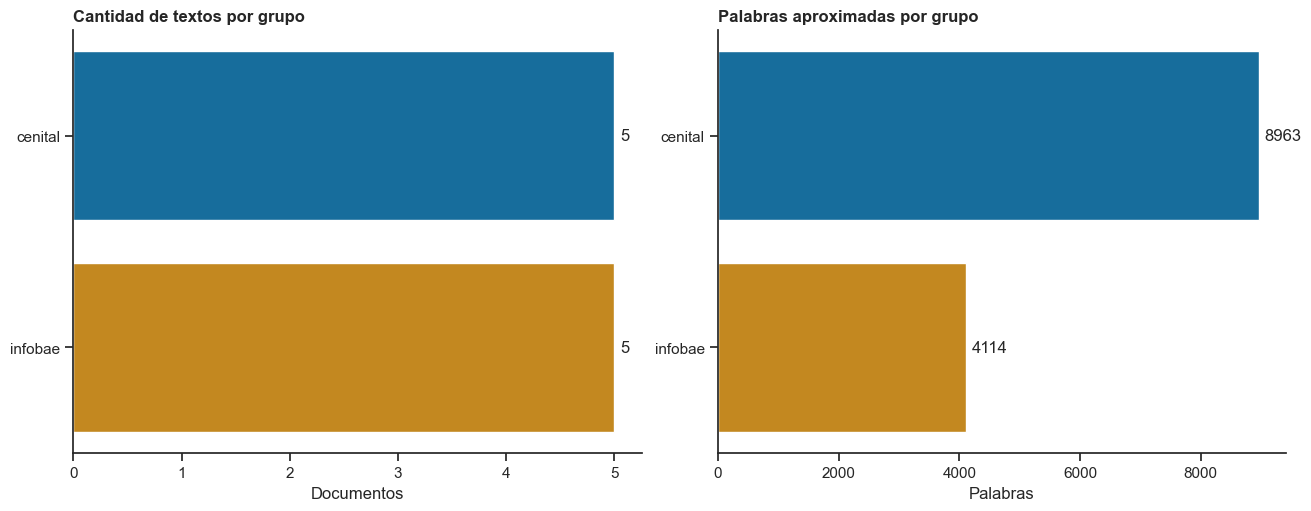

In [6]:
# Gráficos de comparación: cantidad de textos y palabras por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel izquierdo: cantidad de documentos
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])

# Panel derecho: palabras totales
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()


**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [7]:
!pip install spacy plotly -q
!python -m spacy download es_core_news_sm -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Juli\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


In [8]:
# Cargamos el modelo de spaCy
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        "`python -m spacy download es_core_news_sm` y volvé a correr el cuaderno."
    ) from error


Modelo cargado correctamente: es_core_news_sm


In [9]:
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico, usa la forma original."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Solo palabras alfabéticas que no sean stopwords
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos entidades nombradas (personas, organizaciones, lugares)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los resultados al DataFrame principal
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head(10))


,titulo,grupo_comparacion,texto_contenido
0,La burbuja de la inteligencia artificial,cenital,proyectar empresa tecnología estadounidense gastar año mil millón dólares inteligencia artificial cifra guardar demasiado relación ganan...
1,"La inteligencia artificial no muestra el pasado, lo reescribe",cenital,febrero openai presentar sociedad sora generador video buscar deslumbrar ejemplo producido texto imagen histórico california fiebre oro ...
2,Elon Musk la quiere detener y a la vez desarrollar,cenital,marzo elon musk pedir detener investigación inteligencia artificial ia líder tecnológico carta desarrollo significar riesgo profundo soc...
3,Changas digitales: qué hay detras de la cortina de las nuevas maneras de ganar dinero en internet,cenital,transición página web economía plataforma gig economy evolución tecnológico llegar ofrecer oportunidad trabajo venta foto pie entrenamie...
4,¿Debí preguntarle a la inteligencia artificial?,cenital,autor nota sebastián ceria miembro academia ingenieria unidos doctor investigación operaciones carnegie mellon unoiversity licenciado ma...
5,La IA cambiará el empleo: estos son los dos perfiles con más futuro,infobae,llegada inteligencia artificial ámbito economía redefineir proceso productivo transformar completo mercado laboral debate profesional lo...
6,Inteligencia artificial y trabajo: la ventaja que más vale en 2026,infobae,empresa empezar medir inteligencia artificial brecha herramienta ofrecer empleador profesional tiempo curiosidad personal convertir habi...
7,La inteligencia artificial acelera despidos y redefine el empleo en el sector tecnológico,infobae,inteligencia artificial concepto futurista redefine lugar sector tecnológico buscar oportunidad empresa influyent ajustar plantilla rees...
8,"Las 10 profesiones que la inteligencia artificial podría reemplazar en la próxima década, según Microsoft",infobae,inteligencia artificial ia promesa lejano redefine mercado trabajo generar duda futuro múltiple profesión estudio microsoft difundido gq...
9,La inteligencia artificial está eliminando empleos para quienes buscan su primer trabajo,infobae,expansión acelerado inteligencia artificial modificar forma producir contenido resolver tarea procesar dato cambiar trabajo reino unido ...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [10]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split())
        for termino, frecuencia in contador.most_common(top_n):
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)


top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)


,grupo,término,frecuencia
0,cenital,ia,59
1,cenital,él,44
2,cenital,red,41
3,cenital,trabajo,40
4,cenital,modelo,25
5,cenital,dólares,23
6,cenital,artificial,23
7,cenital,texto,23
8,cenital,empresa,22
9,cenital,inteligencia,22


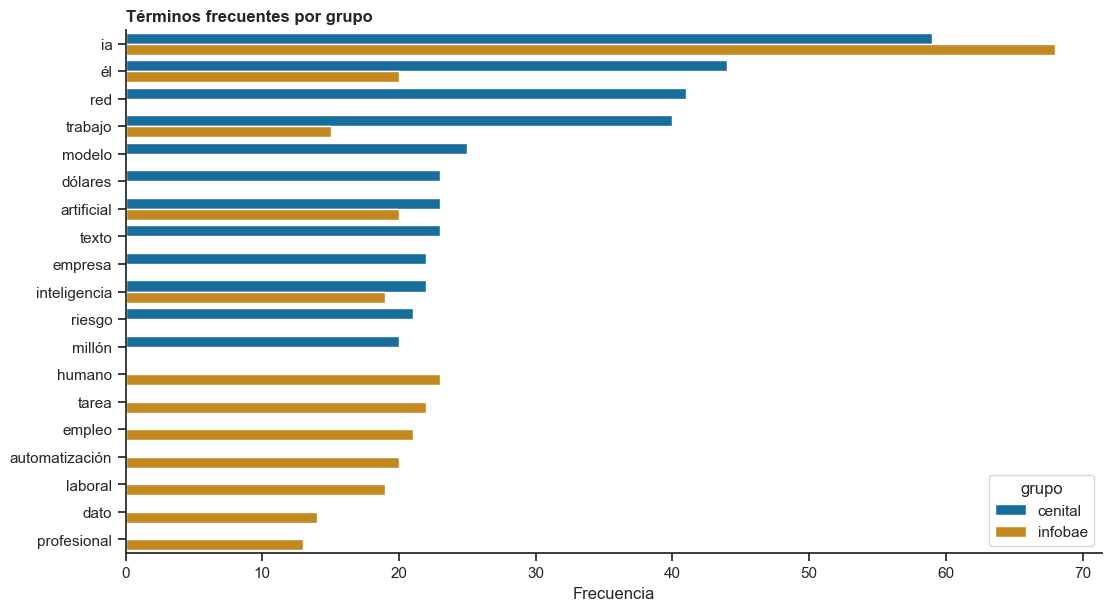

In [11]:
# Gráfico comparativo: términos frecuentes por grupo
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",
    y="término",
    hue="grupo",
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


In [12]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos y ordenamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )
    display(top_entidades.head(TOP_N * 2))
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")


,grupo,texto_entidad,etiqueta,frecuencia
123,cenital,IA,LOC,20
46,cenital,ChatGPT,MISC,14
229,cenital,OpenAI,MISC,11
317,cenital,¿,LOC,8
248,cenital,Por eso,MISC,7
251,cenital,Puerto Rico,LOC,7
120,cenital,Grok,PER,6
7,cenital,Acá,PER,5
43,cenital,Cenital,LOC,5
115,cenital,Google,ORG,5


El codigo anterior no me esta mostrando un primer acercamiento con infobae a causa del corte de ranking

In [13]:
display(top_entidades[top_entidades["grupo"] == "infobae"].head(20))

,grupo,texto_entidad,etiqueta,frecuencia
384,infobae,IA,LOC,35
427,infobae,Microsoft,ORG,10
342,infobae,ChatGPT,MISC,5
370,infobae,Forbes,ORG,5
369,infobae,Fiverr,PER,3
371,infobae,Foro Económico Mundial,ORG,3
373,infobae,GQ,ORG,3
436,infobae,OpenAI,MISC,3
476,infobae,en Estados Unidos,LOC,3
326,infobae,Alex Karp,PER,2


In [14]:
# --- Bigramas por grupo ---
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"])

# Convertimos a DataFrame con títulos como índice
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos bigramas dentro de cada grupo
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()
    .T
)

# Extraemos los top_n bigramas de cada grupo
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)


,grupo,bigrama,frecuencia
0,cenital,inteligencia artificial,21
1,cenital,red neuronal,16
2,cenital,mil millón,12
3,cenital,red social,12
4,cenital,puerto rico,7
5,cenital,open ai,7
6,cenital,modelo lenguaje,7
7,cenital,millón dólares,7
8,cenital,bad bunny,6
9,cenital,cajita texto,5


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [15]:
# Concatenamos todos los textos de contenido de cada grupo en un solo string
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)
    .agg(texto_modelo=("texto_contenido", " ".join))
    .rename(columns={COLUMNA_GRUPO: "grupo"})
)

display(corpus_por_grupo)


,grupo,texto_modelo
0,cenital,proyectar empresa tecnología estadounidense gastar año mil millón dólares inteligencia artificial cifra guardar demasiado relación ganan...
1,infobae,llegada inteligencia artificial ámbito economía redefineir proceso productivo transformar completo mercado laboral debate profesional lo...


In [16]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila), extrae los top_n términos con mayor valor."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(registros)


# --- Bag of Words ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"])
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)


Top de términos según Bag of Words


,grupo,término,frecuencia
0,cenital,red,41.0
1,cenital,dólares,23.0
2,cenital,usuario,18.0
3,cenital,pedir,17.0
4,cenital,neuronal,16.0
5,cenital,mil,14.0
6,cenital,ai,12.0
7,cenital,foto,12.0
8,cenital,ejemplo,12.0
9,cenital,entrenar,11.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,cenital,red,0.4083
1,cenital,dólares,0.2290
2,cenital,usuario,0.1792
3,cenital,pedir,0.1693
4,cenital,neuronal,0.1593
5,cenital,mil,0.1394
6,cenital,ai,0.1195
7,cenital,foto,0.1195
8,cenital,ejemplo,0.1195
9,cenital,entrenar,0.1095


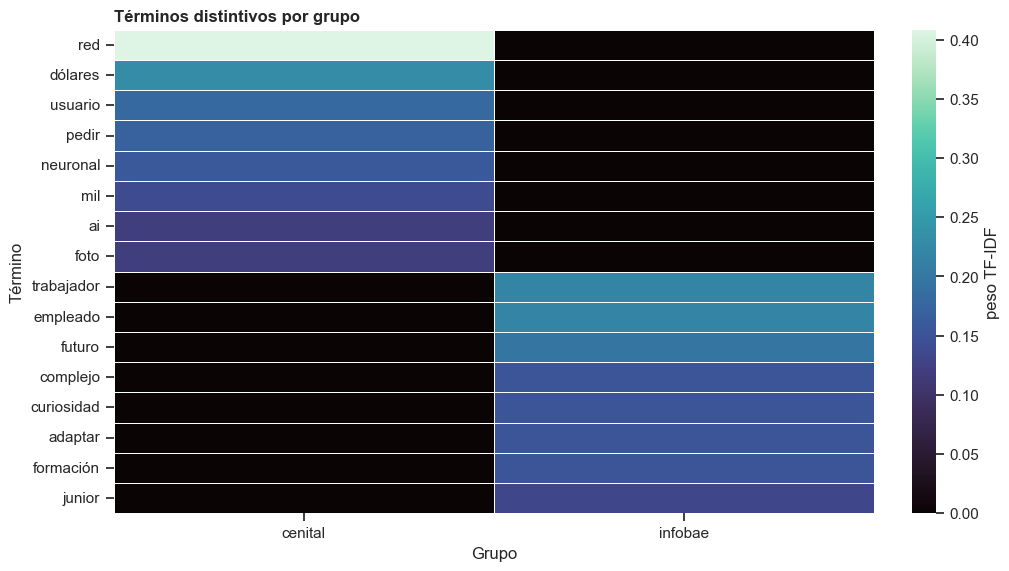

In [17]:
# Mapa de calor: términos distintivos por grupo
# Seleccionamos los top-8 términos TF-IDF de cada grupo (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()


**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [18]:
# Tomamos los 2 términos más distintivos de cada grupo
terminos_para_volver = top_tfidf.groupby("grupo").head(4).reset_index(drop=True)
display(terminos_para_volver)


,grupo,término,tfidf
0,cenital,red,0.4083
1,cenital,dólares,0.2290
2,cenital,usuario,0.1792
3,cenital,pedir,0.1693
4,infobae,trabajador,0.2183
5,infobae,empleado,0.2183
6,infobae,futuro,0.1965
7,infobae,complejo,0.1528


In [19]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve
    hasta max_fragmentos centrados en la primera aparición de cada texto."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)
        coincidencia = patron.search(texto)
        if not coincidencia:
            continue

        # Recortamos una ventana alrededor de la primera aparición
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Agregamos "..." si el fragmento no empieza/termina con el texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:
            break
    return registros


# --- Buscamos los fragmentos para cada término distintivo ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)


,grupo,término,título,fragmento
0,cenital,red,La burbuja de la inteligencia artificial,"...las necesarias, se tendió más cable del que se podía usar. Pero una vez que el humo de la especulación se disipó, quedó algo tangible..."
1,cenital,red,Elon Musk la quiere detener y a la vez desarrollar,"...datos. Si se equivoca al resolver un problema, fortalece algunas conexiones y debilita otras, hasta que la interacción de las señales..."
2,cenital,red,¿Debí preguntarle a la inteligencia artificial?,"...lo que pasa, te pedimos que nos des una mano para seguir.\nSumatePara ver las repercusiones de su éxito de audiencias usé el buscador..."
3,cenital,dólares,La burbuja de la inteligencia artificial,Se proyecta que las empresas de tecnología estadounidenses gastarán sólo este año más de 500 mil millones de dólares en inteligencia art...
4,cenital,dólares,"La inteligencia artificial no muestra el pasado, lo reescribe","...n marzo de 2026 OpenAI decidió liquidar a Sora de manera abrupta. Esta carísima prueba de concepto, que suponía una pérdida de un mil..."
5,cenital,dólares,Changas digitales: qué hay detras de la cortina de las nuevas maneras de ganar dinero en internet,"...s noticias al respecto fueron de entrenamientos fueron mano de obra esclava de Filipinas, Kenia, Colombia o Venezuela pagaban a centa..."
6,cenital,usuario,¿Debí preguntarle a la inteligencia artificial?,...creado espacios en los que prospera la desinformación y los usuarios tienen dificultades para discernir la realidad de la ficción. En...
7,cenital,pedir,Elon Musk la quiere detener y a la vez desarrollar,...primera empresa en conseguir usuarios regulares amenaza quedarse con todo. El resto de los líderes de la industria no tiene otra opci...
8,infobae,trabajador,Inteligencia artificial y trabajo: la ventaja que más vale en 2026,"...habilidades.\nLos programas institucionales de entrenamiento son necesarios, pero no suficientes. El complemento se encuentra en lo q..."
9,infobae,futuro,La IA cambiará el empleo: estos son los dos perfiles con más futuro,"...n el centro de la agenda tecnológica.\nAlex Karp, CEO de Palantir, lo sintetizó en una frase: “Solo hay dos tipos de trabajadores que..."


## 10. Escritura interpretativa
Agreguen una o más celdas Markdown nuevas y respondan estas preguntas:

1. **Recorte y comparación**

- ¿Qué comparan exactamente?
- ¿Qué vuelve válidos esos dos grupos como contraste?
Este trabajo compara diez artículos periodísticos sobre IA y empleo publicados entre 2024 y 2026.

2. **Lectura distante**

- ¿Qué términos, entidades o asociaciones lexicales organizan cada grupo?
- ¿Qué diferencias aparecen con más claridad cuando miran TF-IDF y no solo frecuencias?

3. **Lectura cercana**

- ¿Cómo aparece en contexto al menos uno de los términos distintivos de cada grupo?
- ¿Qué cambia cuando vuelven al fragmento?

4. **Visualización y método**

- ¿Qué gráfico ayudó realmente a comprender mejor el contraste?
- ¿Qué límites tiene este enfoque para leer discurso?
- ¿Qué no se puede afirmar solo con estas representaciones sparse?

1. La elección de estos dos medios responde a que representan dos lógicas periodísticas distintas: una orientada al análisis profundo y otra a la información rápida. Cenital, como dice en su página, es un medio de periodismo financiado por suscriptores de tipo newsletter, que desarrolla los temas con profundidad, análisis y contexto. Infobae es un medio financiado por publicidad, que produce notas más breves orientadas a la viralización y al consumo rápido de información al estilo de las RRSS. El contraste es válido porque ambos cubren el mismo tema en el mismo período, pero desde lugares distintos: Cenital mira el fenómeno desde las empresas, la inversión y las consecuencias para la sociedad en su conjunto. Infobae lo mira desde el trabajador individual y lo que tiene que hacer para no quedarse afuera.

2. lectura distante

El análisis (en este punto de lectura distante) muestra que ambos grupos comparten los términos "ia", "artificial", "inteligencia", "trabajo". En Cenital los términos más distintivos son "red", "modelo", "dólares", "riesgo", "millón", "empresa", mientras que en infobae los términos "humano", "tarea", "automatización", "laboral", "dato", "profesional".Se puede observar “ruido” / errores como “el”, ya que no se filtró correctamente la stopword.

Mas adelante con los bigramas podemos notar un poco más al nombrar "red neuronal", "mil millón", "red social", "modelo lenguaje", "millón dólares", "despabilar lector", vs infobae con "director ejecutivo", "consultora global", "ia reemplazar", "caída vacante", "aprender ia".

En el caso de Cenital, las entidades y asociaciones léxicas más frecuentes son “IA”, “ChatGPT”, “OpenAI”, Google. Se destacan “Elon Musk” (y su variante “Musk”) y lo llamativo es lo de Bad Bunny y OnlyFans. Se organizan principalmente alrededor de la IA como concepto y herramientas.

En el caso de infobae son más claros en cuanto al entorno de la IA: se menciona además de los términos que comparte con cenital como más frecuentes, como IA y ChatGPT, a “Microsoft”, “Forbes”, “Financial Times”, “KPMG”, entidades muy asociadas al mundo corporativo. También podemos ver eso con las PER, que giran en torno a “Alex Karp”, “Josh Bersin” y “Chen”, expertos del ámbito empresarial.

Al incorporar TF-IDF, las diferencias se vuelven un poco más claras, ya que no solo se consideran las palabras más frecuentes sino las más representativas. Se refuerza que términos como “red” o “dolares” en Cenital, y “trabajador”, “empleado” o “futuro” en infobae, no solo aparecen mucho sino que caracterizan cada discurso.

Como conclusión, en este punto siento que con infobae se puede percibir un poco más de qué está hablando, mientras que cenital nombra términos asociados a dinero, “red” y “neuronal”. Pero sin leer el texto en una lectura cercana, es más difícil deducir de qué podría estar hablando cenital solo desde la lectura distante.


3.
Cenital: El uso de "Red"
En las fuentes de Cenital, este término aparece ligado a la arquitectura tecnológica, principalmente explicando qué son y cómo funcionan las redes neuronales. No es casual que el artículo con más palabras se destaque por hablar de este tema, que es el de Elon Musk: Elon Musk la quiere detener y, a la vez, desarrollar. Los peligros de liberar o dominar la Inteligencia Artificial.

También se menciona en el segundo artículo con más palabras de Cenital, hablando ya no tanto de la arquitectura, sino de la red social X y un análisis y reflexión con respecto a una canción de Bad Bunny, entre la respuesta de un LLM vs. lo que se dice en la red social.

También en el análisis se puede observar que, de las 41 veces que se repite en frecuencia la palabra red, 16 se asocian con neuronal y 12 con red social.

Infobae: El uso de "Trabajador"
Este término aparece ligado al individuo dentro de la lógica de productividad y el mercado laboral formal. Es un sujeto activo que debe aprender IA en su tiempo libre como una ventaja competitiva.


4.
- Las tablas fueron las que más me ayudaron a ver contrastes.
- Los límites que tiene, al igual que en el TPI_1, son, primero, el corpus: con 5 textos de cada grupo podemos tener unas primeras exploraciones, pero no generalizar. Necesitamos ampliar el corpus. Como punto 2, se notaron muchas stopwords en el análisis, lo que afecta la calidad del análisis, principalmente en Cenital.
- Sobre lo que no puede afirmarse: TF-IDF muestra qué palabras son distintivas de cada grupo, pero no puede explicar por qué ni con qué intención se usan. Para eso es imprescindible la lectura cercana de fragmentos.

In [ ]:
# --- Exportación opcional de tablas auxiliares ---
EXPORTAR_RESULTADOS = False
CARPETA_SALIDA = Path("salidas_tpi2")

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")


Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

- ¿El corpus tiene entre 6 y 10 textos y exactamente dos grupos comparables?
- ¿La columna `grupo_comparacion` está completa y bien usada?
- ¿Usaron `spaCy`, `Bag of Words`, `TF-IDF` y al menos una lectura de bigramas?
- ¿Incluyeron al menos dos visualizaciones analíticas legibles?
- ¿Volvieron al menos a tres fragmentos concretos?
- ¿Hay una interpretación final y una sección explícita de límites?
- ¿El notebook corre de principio a fin sin depender de ediciones manuales intermedias?

Si pueden responder que sí a todo, la entrega ya tiene la estructura mínima esperada para el TPI 2.
